In [2]:
import os
# Force clear the environment variable to let PyTorch auto-detect
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    del os.environ['CUDA_VISIBLE_DEVICES']

import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device Count: {torch.cuda.device_count()}")


CUDA Available: True
Device Count: 1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ultralytics
from ultralytics import YOLO

# Check installation and version
ultralytics.checks()


Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 23.3 GB RAM, 93.9/952.8 GB disk)


In [ ]:
# load train, validation, and test data
data_config = 'VisDrone.yaml'


In [ ]:
# Load a pretrained YOLO26 model
model = YOLO("yolo26n.pt") 

# Start training
results = model.train(
    data=data_config,
    epochs=10,                          # Set epochs based on your requirement
    device=0,
    imgsz=640,                          # Image resolution
    batch=8,                            # Adjust based on your GPU memory
    name='yolo26_visdrone_baseline',
    plots=True                          # Generates the loss curves required for Part II
)


Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_visdrone_baseline3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

Plot successfully generated and saved as 'training_validation_metrics.png'


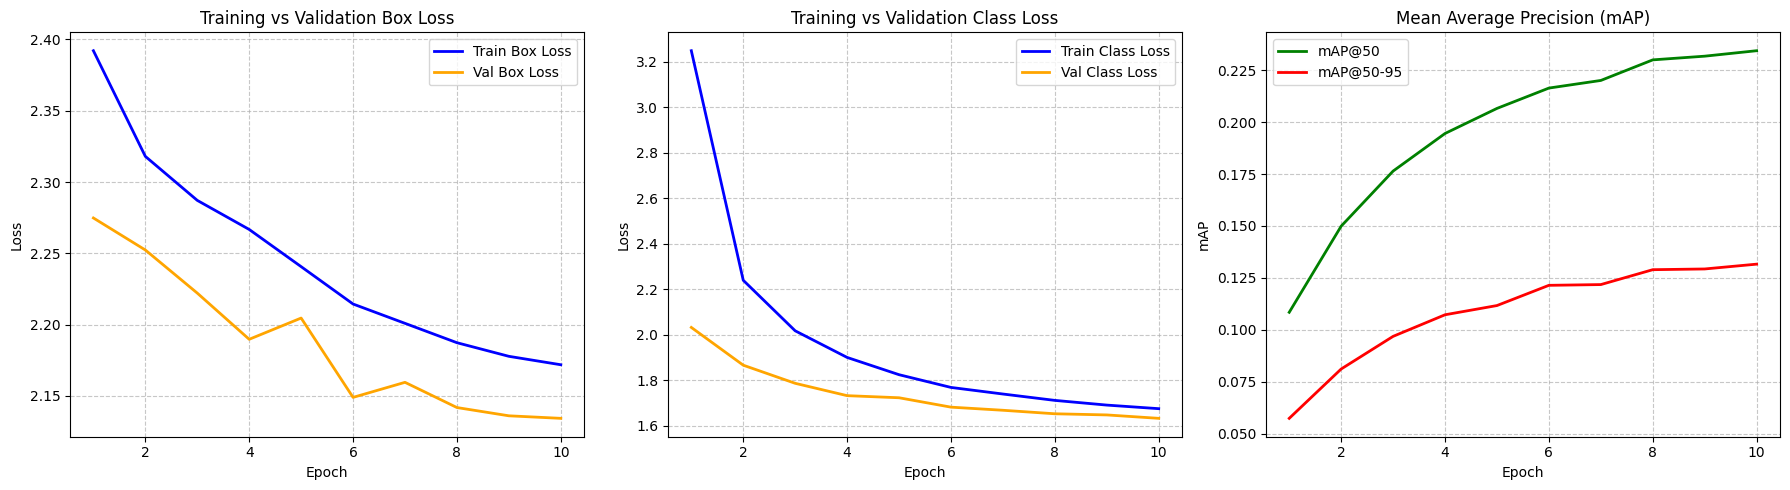

In [ ]:
# Load the results.csv file
df = pd.read_csv('results.csv')

# YOLO result column names often have leading spaces, so we strip them
df.columns = df.columns.str.strip()

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Box Loss (Training vs Validation)
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue', linewidth=2)
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange', linewidth=2)
axes[0].set_title('Training vs Validation Box Loss', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('Loss', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Plot Class Loss (Training vs Validation)
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='blue', linewidth=2)
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='orange', linewidth=2)
axes[1].set_title('Training vs Validation Class Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Plot Mean Average Precision (mAP)
axes[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green', linewidth=2)
axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='red', linewidth=2)
axes[2].set_title('Mean Average Precision (mAP)', fontsize=12)
axes[2].set_xlabel('Epoch', fontsize=10)
axes[2].set_ylabel('mAP', fontsize=10)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap and save the figure
plt.tight_layout()
plt.savefig('training_validation_metrics.png', dpi=300)
print("Plot successfully generated and saved as 'training_validation_metrics.png'")


In [6]:
# Load your trained model weights
model = YOLO('runs/detect/train/weights/best.pt')

# Run validation on your dataset (this automatically computes the correct object detection metrics)
metrics = model.val() 

# You can access the exact numbers for your comparison table here:
print(f"Overall Precision: {metrics.results_dict['metrics/precision(B)']}")
print(f"Overall Recall: {metrics.results_dict['metrics/recall(B)']}")
print(f"mAP@50: {metrics.results_dict['metrics/mAP50(B)']}")


Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 4.92.4 MB/s, size: 54.0 KB)
val: Scanning D:\Uni\Year4\CMPE_401\YOLOProject\datasets\coco8\labels\val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3s/it 2.3s
                   all          4         17      0.906      0.646      0.888      0.702
                person          3         10          1      0.376      0.804       0.42
                   dog          1          1      0.795          1      0.995      0.895
                 horse          1          2       0.86          1      0.995      0.798
              elephant          1          2      0.782        0.5      0.543      0.309
              umbr

In [3]:
print("Variable: imgsz = 1024 (Control was 640)")

# Load the raw, pre-trained nano weights (same starting point as baseline)
model = YOLO('yolo26n.pt')

# Train the model with the experimental variable
results = model.train(
    data='VisDrone.yaml',         
    epochs=10,                    # Variable kept at 10
    device=0,
    imgsz=1024,                   # Variable for experiment: Increased from 640
    batch=8,                      # Adjust based on your GPU memory
    name='exp_resolution_1024',   # Organizes output cleanly
    project='runs/detect',                    
)


Variable: imgsz = 1024 (Control was 640)
New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.6 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mos

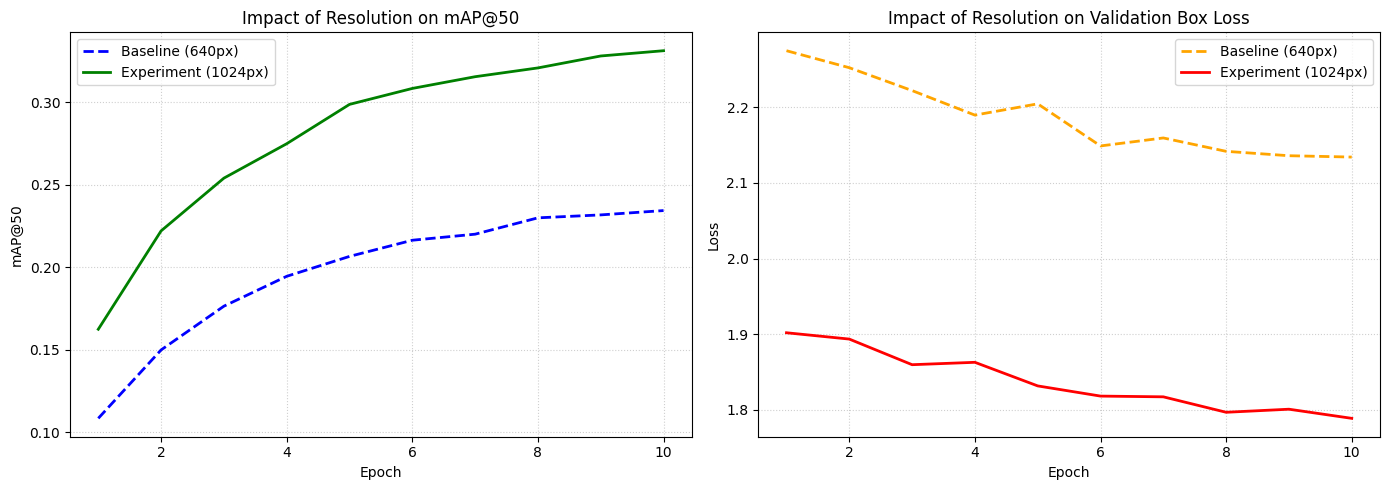

Plot saved as 'experiment_1_comparison.png'


In [4]:
# Ensure plots render directly in the notebook
%matplotlib inline

# NOTE: Update 'train3' to the exact folder name of your best baseline run
baseline_csv_path = 'runs/detect/yolo26_visdrone_baseline3/results.csv'
experiment_csv_path = 'runs/detect/runs/detect/exp_resolution_1024/results.csv'

# Load data
df_base = pd.read_csv(baseline_csv_path)
df_exp = pd.read_csv(experiment_csv_path)

# Strip whitespace from column names
df_base.columns = df_base.columns.str.strip()
df_exp.columns = df_exp.columns.str.strip()

# Create a 1x2 grid for our comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. mAP@50 Comparison Plot
axes[0].plot(df_base['epoch'], df_base['metrics/mAP50(B)'], label='Baseline (640px)', color='blue', linestyle='--', linewidth=2)
axes[0].plot(df_exp['epoch'], df_exp['metrics/mAP50(B)'], label='Experiment (1024px)', color='green', linewidth=2)
axes[0].set_title('Impact of Resolution on mAP@50', fontsize=12)
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('mAP@50', fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Validation Box Loss Comparison Plot
axes[1].plot(df_base['epoch'], df_base['val/box_loss'], label='Baseline (640px)', color='orange', linestyle='--', linewidth=2)
axes[1].plot(df_exp['epoch'], df_exp['val/box_loss'], label='Experiment (1024px)', color='red', linewidth=2)
axes[1].set_title('Impact of Resolution on Validation Box Loss', fontsize=12)
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

# Adjust layout and display the plot inline
plt.tight_layout()
plt.show()

# Save the figure to your directory so you can upload it to your README later
fig.savefig('experiment_1_comparison.png', dpi=300)
print("Plot saved as 'experiment_1_comparison.png'")
